In [6]:
import duckdb
import tensorflow as tf
import numpy as np

def duckdb_generator(query, batch_size=100_000):
    con = duckdb.connect("my_data.duckdb")
    result = con.execute(query)
    while True:
        chunk = result.fetch_df_chunk(batch_size)
        if len(chunk) == 0:  # stop when no more rows
            break
        X = chunk.drop(columns=["tip_category"]).to_numpy().astype("float32")
        y = chunk["tip_category"].to_numpy().astype("int32")
        yield X, y

query = """
WITH CTE_yellow_2009 AS (
    SELECT 
        CAST(Trip_Pickup_DateTime AS TIMESTAMP) AS pick_up_time,
        CAST(Trip_Dropoff_DateTime AS TIMESTAMP) AS drop_off_time,
        CAST(Passenger_Count AS INTEGER) AS passenger_count,
        CAST(Trip_Distance AS INTEGER) AS trip_distance,
        Payment_Type AS payment_type,
        CAST(Total_Amt AS FLOAT)   AS total_amount,
        Tip_Amt AS tip_amount,
        CAST(Tip_Amt AS FLOAT)   AS tip_amount,
        CAST( CASE Payment_Type
            WHEN  'Credit' THEN 1
            WHEN  'CREDIT' THEN 1
            ELSE 2
        END AS INTEGER) AS payment_category,
        CAST( CASE Tip_Amt
            WHEN  0.0 THEN 1
            ELSE 0
        END AS INTEGER) AS tip_category
    FROM 'C:/Users/ekadw/Documents/DATA/NY_Taxi/2009/yellow_taxi_2009/yellow_tripdata_2009-01.parquet'
    WHERE Trip_Pickup_DateTime IS NOT NULL
        AND Trip_Dropoff_DateTime IS NOT NULL
        AND Passenger_Count >= 0
        AND Trip_Distance >= 0 
        AND Trip_Distance <= 50
        AND Payment_Type IS NOT NULL
        AND Total_Amt >= 0
        AND Tip_Amt >= 0
        AND Trip_Pickup_DateTime >= '2009-01-01' 
        AND Trip_Pickup_DateTime < '2010-01-01'
), CTE_duration_yellow_2009 AS (
    SELECT
        pick_up_time,
        drop_off_time,
        passenger_count,
        trip_distance,
        total_amount,
        payment_category,
        tip_category,
        DATE_DIFF('day', pick_up_time, drop_off_time) AS duration_days,
        EPOCH(drop_off_time - pick_up_time) AS duration_seconds
    FROM CTE_yellow_2009
    WHERE payment_category = 1
)

SELECT 
    passenger_count,
    trip_distance,
    total_amount,
    CAST(duration_seconds AS FLOAT)   AS duration_seconds,
    tip_category
FROM CTE_duration_yellow_2009
WHERE duration_days = 0
"""

# Signature (for TensorFlow Dataset)
output_signature = (
    tf.TensorSpec(shape=(None, 4), dtype=tf.float32),
    tf.TensorSpec(shape=(None,), dtype=tf.int32),
)

dataset = tf.data.Dataset.from_generator(
    lambda: duckdb_generator(query, batch_size=100_000),
    output_signature=output_signature
)

# Shuffle + mini-batch for GPU training
dataset = dataset.unbatch().shuffle(10_000).batch(64).prefetch(tf.data.AUTOTUNE)


In [7]:
# Sample ~1M rows to compute class weights
sample = duckdb.connect("my_data.duckdb").execute(
    """
    WITH CTE_yellow_2009 AS (
    SELECT 
        CAST(Trip_Pickup_DateTime AS TIMESTAMP) AS pick_up_time,
        CAST(Trip_Dropoff_DateTime AS TIMESTAMP) AS drop_off_time,
        CAST(Passenger_Count AS INTEGER) AS passenger_count,
        CAST(Trip_Distance AS INTEGER) AS trip_distance,
        Payment_Type AS payment_type,
        CAST(Total_Amt AS FLOAT)   AS total_amount,
        Tip_Amt AS tip_amount,
        CAST(Tip_Amt AS FLOAT)   AS tip_amount,
        CAST( CASE Payment_Type
            WHEN  'Credit' THEN 1
            WHEN  'CREDIT' THEN 1
            ELSE 2
        END AS INTEGER) AS payment_category,
        CAST( CASE Tip_Amt
            WHEN  0.0 THEN 1
            ELSE 0
        END AS INTEGER) AS tip_category
    FROM 'C:/Users/ekadw/Documents/DATA/NY_Taxi/2009/yellow_taxi_2009/yellow_tripdata_2009-01.parquet'
    WHERE Trip_Pickup_DateTime IS NOT NULL
        AND Trip_Dropoff_DateTime IS NOT NULL
        AND Passenger_Count >= 0
        AND Trip_Distance >= 0 
        AND Trip_Distance <= 50
        AND Payment_Type IS NOT NULL
        AND Total_Amt >= 0
        AND Tip_Amt >= 0
        AND Trip_Pickup_DateTime >= '2009-01-01' 
        AND Trip_Pickup_DateTime < '2010-01-01'
), CTE_duration_yellow_2009 AS (
    SELECT
        pick_up_time,
        drop_off_time,
        passenger_count,
        trip_distance,
        total_amount,
        payment_category,
        tip_category,
        DATE_DIFF('day', pick_up_time, drop_off_time) AS duration_days,
        EPOCH(drop_off_time - pick_up_time) AS duration_seconds
    FROM CTE_yellow_2009
    WHERE payment_category = 1
)

SELECT 
    tip_category
FROM CTE_duration_yellow_2009
WHERE duration_days = 0
LIMIT 1000000
"""
).fetch_df()

classes, counts = np.unique(sample["tip_category"], return_counts=True)
class_weights = {cls: (len(sample) / (len(classes) * count)) for cls, count in zip(classes, counts)}
print("Class Weights:", class_weights)


Class Weights: {np.int32(0): np.float64(0.515768061165966), np.int32(1): np.float64(16.35483448907497)}


In [8]:
from tensorflow.keras import layers, Sequential

model = Sequential([
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid")   # sigmoid for binary classification
])

model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])

model.fit(dataset, epochs=5, class_weight=class_weights)


Epoch 1/5
46693/46693 ━━━━━━━━━━━━━━━━━━━━ 118s 2ms/step - accuracy: 0.6390 - loss: 3.4836
Epoch 2/5


C:\Users\ekadw\anaconda3\envs\Tensorflow31018\lib\site-packages\keras\src\trainers\epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


46693/46693 ━━━━━━━━━━━━━━━━━━━━ 118s 2ms/step - accuracy: 0.7443 - loss: 0.6414
Epoch 3/5


C:\Users\ekadw\anaconda3\envs\Tensorflow31018\lib\site-packages\keras\src\trainers\epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


46693/46693 ━━━━━━━━━━━━━━━━━━━━ 118s 2ms/step - accuracy: 0.7583 - loss: 0.5286
Epoch 4/5


C:\Users\ekadw\anaconda3\envs\Tensorflow31018\lib\site-packages\keras\src\trainers\epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


46693/46693 ━━━━━━━━━━━━━━━━━━━━ 116s 2ms/step - accuracy: 0.7634 - loss: 0.5108
Epoch 5/5


C:\Users\ekadw\anaconda3\envs\Tensorflow31018\lib\site-packages\keras\src\trainers\epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


46693/46693 ━━━━━━━━━━━━━━━━━━━━ 76s 1ms/step - accuracy: 0.7681 - loss: 0.49012


C:\Users\ekadw\anaconda3\envs\Tensorflow31018\lib\site-packages\keras\src\trainers\epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt

y_true_all, y_pred_all, y_prob_all = [], [], []

for X_batch, y_batch in duckdb_generator(query, batch_size=100_000):
    y_prob = model.predict(X_batch, verbose=0).ravel()   # probabilities
    y_pred = (y_prob >= 0.848).astype(int)                # threshold 0.5
    
    y_true_all.extend(y_batch)
    y_pred_all.extend(y_pred)
    y_prob_all.extend(y_prob)


In [12]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_true_all, y_prob_all)
f1_scores = 2 * (precision * recall) / (precision + recall)
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]

print(f"Best Threshold = {best_threshold:.3f}")
print(f"Best F1 = {f1_scores[best_idx]:.3f}")


Best Threshold = 0.848
Best F1 = 0.323


In [14]:
acc = accuracy_score(y_true_all, y_pred_all)
prec = precision_score(y_true_all, y_pred_all)
rec = recall_score(y_true_all, y_pred_all)
f1 = f1_score(y_true_all, y_pred_all)

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1: {f1:.4f}")


Accuracy: 0.9546
Precision: 0.2952
Recall: 0.3546
F1: 0.3222


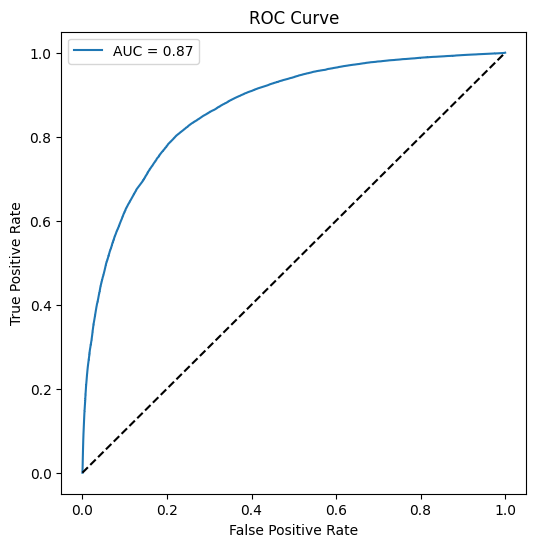

In [15]:
fpr, tpr, _ = roc_curve(y_true_all, y_prob_all)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
